# Exploración de Datos de Diabetes con PySpark

Este notebook realiza la carga y exploración inicial del dataset `diabetes_v1_.csv` utilizando PySpark.

Integrantes: Sebastián Mendieta, Samuel Reyes, Jean Villavicencio.

In [ ]:
import os
import sys

# Apuntar Spark al Python del virtualenv actual (esto estaba dañao)
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

from pyspark.sql import SparkSession
from pyspark.sql.types import DoubleType, IntegerType, FloatType, LongType, StringType


# Inicializar la sesión de Spark
spark = SparkSession.builder \
    .appName("DiabetesDataExploration") \
    .getOrCreate()

spark

## 1. Carga del Dataset

In [ ]:
# Cargar el dataset en un DataFrame de PySpark
file_path = "diabetes_v1_.csv"

# Asumimos que el CSV tiene encabezado y Spark infiere el esquema y si valió
df = spark.read.csv(file_path, header=True, inferSchema=True)

# Mostrar el esquema inferido
df.printSchema()

root
 |-- encounter_id: integer (nullable = true)
 |-- patient_nbr: integer (nullable = true)
 |-- race: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: string (nullable = true)
 |-- weight: string (nullable = true)
 |-- admission_type_id: integer (nullable = true)
 |-- discharge_disposition_id: integer (nullable = true)
 |-- admission_source_id: integer (nullable = true)
 |-- time_in_hospital: integer (nullable = true)
 |-- payer_code: string (nullable = true)
 |-- medical_specialty: string (nullable = true)
 |-- num_lab_procedures: integer (nullable = true)
 |-- num_procedures: integer (nullable = true)
 |-- num_medications: integer (nullable = true)
 |-- number_outpatient: integer (nullable = true)
 |-- number_emergency: integer (nullable = true)
 |-- number_inpatient: integer (nullable = true)
 |-- diag_1: string (nullable = true)
 |-- diag_2: string (nullable = true)
 |-- diag_3: string (nullable = true)
 |-- number_diagnoses: integer (nullable = true)
 |-

In [10]:
# Mostrar las primeras filas del dataset
df.show(5)

+------------+-----------+---------------+------+-------+------+-----------------+------------------------+-------------------+----------------+----------+-----------------+------------------+--------------+---------------+-----------------+----------------+----------------+------+------+------+----------------+-------------+---------+---------+-----------+-----------+--------------+-----------+-------------+---------+---------+-----------+------------+-------------+--------+--------+------------+----------+-------+-----------+-------+-------------------+-------------------+------------------------+-----------------------+----------------------+------+----------+
|encounter_id|patient_nbr|           race|gender|    age|weight|admission_type_id|discharge_disposition_id|admission_source_id|time_in_hospital|payer_code|medical_specialty|num_lab_procedures|num_procedures|num_medications|number_outpatient|number_emergency|number_inpatient|diag_1|diag_2|diag_3|number_diagnoses|max_glu_serum|A

### Conclusión de la Carga de Datos

El dataset se ha cargado correctamente infiriendo un esquema inicial de **50 columnas**. Observamos una gran mezcla de variables de identificación (`encounter_id`, `patient_nbr`), demográficas (`race`, `gender`, `age`), y una gran cantidad de atributos clínicos. Esto confirma que estamos ante un conjunto de datos tuco. Ideal para descubrir patrones clínicos relevantes y realizar modelos analíticos de alto valor.

## 2. Resumen de Variables Numéricas

In [11]:
# Identificar columnas numéricas
numeric_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, (DoubleType, IntegerType, FloatType, LongType))]

if numeric_cols:
    print("Variables Numéricas:", numeric_cols)
    # Mostrar estadísticas descriptivas de algunas variables numéricas
    # Para no saturar, mostramos de las primeras 5
    df.select(numeric_cols[:5]).summary().show()
else:
    print("No se encontraron variables numéricas.")

Variables Numéricas: ['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
+-------+--------------------+-------------------+------------------+------------------------+-------------------+
|summary|        encounter_id|        patient_nbr| admission_type_id|discharge_disposition_id|admission_source_id|
+-------+--------------------+-------------------+------------------+------------------------+-------------------+
|  count|               50883|              50883|             50883|                   50883|              50883|
|   mean|1.6535933328754202E8|5.432715677878663E7|2.0283788298645913|      3.6985830237996975|  5.752373091209245|
| stddev|1.0242932135315599E8|3.861430652354145E7|1.4524350746646209|       5.254234130192393|  4.061910099217601|
|    min|               1

### Conclusión del Resumen Numérico

Al observar las métricas centrales, confirmamos que contamos con un dataset toraso **50,000 registros**. Identificamos un total de **13 variables numéricas**. Las estadísticas descriptivas básicas, como la media y la desviación estándar, nos indican que existe una variabilidad importante en los datos (por ejemplo, en el tipo de admisión o tiempo en hospital), lo que sugiere que nuestra población de pacientes es diversa en cuanto a que se complica y el manejo de su condición médica.

## 3. Resumen de Variables Categóricas

In [12]:
# Identificar columnas categóricas (Strings)
categorical_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, StringType)]

if categorical_cols:
    print("Variables Categóricas:", categorical_cols)
    for col_name in categorical_cols[:3]: # Limitamos a 3 para no saturar la salida
        print(f"\nConteo de valores para la columna: {col_name}")
        df.groupBy(col_name).count().orderBy("count", ascending=False).show()
else:
    print("No se encontraron variables categóricas.")

Variables Categóricas: ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'readmitted']

Conteo de valores para la columna: race
+---------------+-----+
|           race|count|
+---------------+-----+
|      Caucasian|38026|
|AfricanAmerican| 9708|
|              ?| 1135|
|       Hispanic|  975|
|          Other|  721|
|          Asian|  318|
+---------------+-----+


Conteo de valores para la columna: gender
+---------------+-----+
|         gender|count|
+---------------+-----+
|         Female|27434|
|           Male

### Conclusión del Resumen Categórico

Este primer paso a las **36 variables categóricas** revela insights demográficos rapedos de encontrar:

- **Raza y Género:** Predomina significativamente la población `Caucasian` (~74%), y existe un balance general entre géneros con una ligera mayoría para `Female`.
- **Edad:** Existe una concentración natural en grupos de la tercera edad (especialmente `[70-80)` y `[60-70)`). 

Estos hallazgos son totalmente predecibles con la naturaleza del problema de la diabetes, afectando en mayor partesita a adultos mayores, y nos dan un excelente punto de partida para segmentar o lo que toque

### Observaciones:
- agregar mas graficos para los tipos de reumenes en las tablas de datos no incluir valores obsolutos sino porcentuales

## 4. Descripción Textual del Dataset

Este dataset contiene registros clínicos de pacientes diabéticos extraídos de hospitales de EE.UU. Su objetivo principal suele ser la predicción de readmisión hospitalaria (`readmitted`), lo cual es crucial para mejorar la calidad del cuidado y reducir costos.

**Características Principales:**
*   **Tamaño:** 50,883 registros y 50 características (features).
*   **Estructura:** Contiene identificadores de pacientes, características demográficas (raza, género, edad), administrativas (tipo de admisión, tiempo en hospital) y características médicas (diagnósticos ICD-9 agrupados, medicamentos como metformina, insulina, y especialidad del médico).
*   **Tipos de datos:** Mayoritariamente variables categóricas representadas como strings (`race`, `gender`, `diag_1`), y algunas variables numéricas discretas (`time_in_hospital`, `num_lab_procedures`).


## 5. Gráficas Resumen de Variables (Visualización)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_46384\2616233711.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=race_pd.sort_values('count', ascending=False), x='race', y='count', palette='viridis')


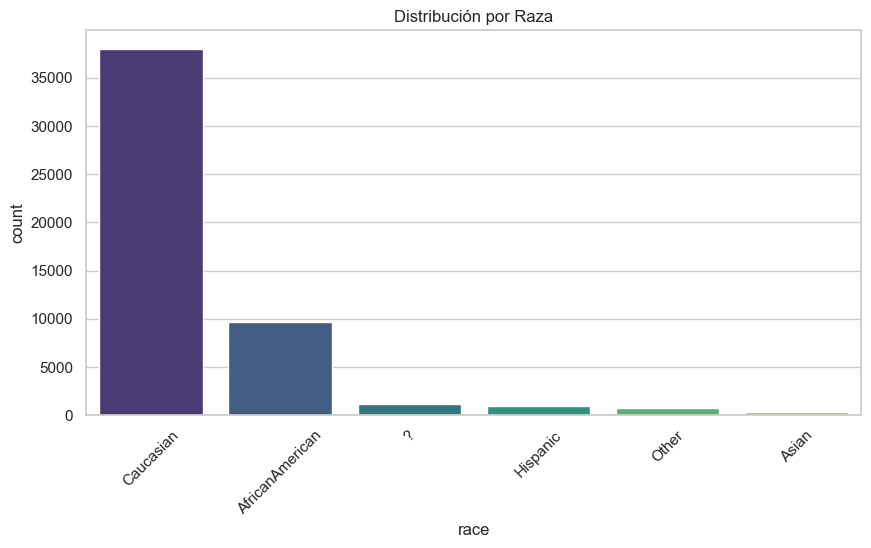

C:\Users\Usuario\AppData\Local\Temp\ipykernel_46384\2616233711.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample_df, x='gender', y='time_in_hospital', palette='Set2')


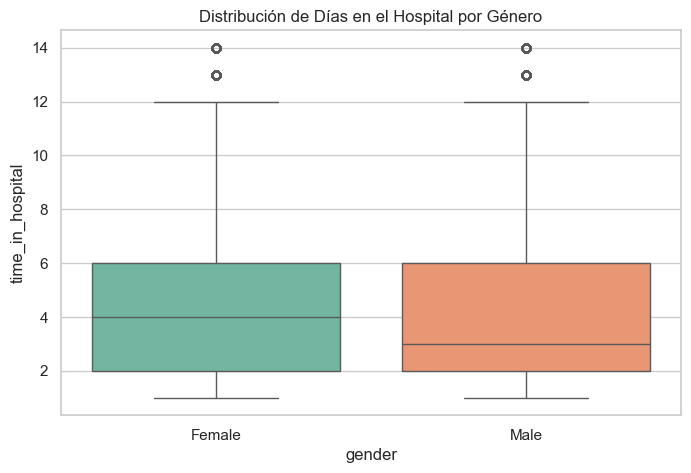

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")

# Gráfico Cualitativo: Distribución de Raza
race_pd = df.groupBy('race').count().toPandas()

plt.figure(figsize=(10, 5))
sns.barplot(data=race_pd.sort_values('count', ascending=False), x='race', y='count', palette='viridis')
plt.title('Distribución por Raza')
plt.xticks(rotation=45)
plt.show()

# Gráfico Cuantitativo: Días en el hospital por género
# Convertimos las columnas necesarias a Pandas para graficar
sample_df = df.select('gender', 'time_in_hospital').toPandas()
# Filtramos géneros desconocidos
sample_df = sample_df[sample_df['gender'].isin(['Male', 'Female'])]

plt.figure(figsize=(8, 5))
sns.boxplot(data=sample_df, x='gender', y='time_in_hospital', palette='Set2')
plt.title('Distribución de Días en el Hospital por Género')
plt.show()


## 6. Preparación y Transformación Textual (Pipeline NLP PySpark)

Dado que este es un dataset clínico tabular estructurado y carece de campos de texto libre como tweets o foros, combinaremos las descripciones de especialidades y los diagnósticos en una sola columna **`texto_clinico`**. 
Insertaremos texto ruidoso simulado (hashtags, @, URLs, signos de puntuación, contracciones) en un registro para demostrar de forma práctica el pipeline de limpieza estipulado en los requerimientos.


In [ ]:
from pyspark.sql.functions import col, concat_ws, lower, regexp_replace, trim, udf, lit, when
from pyspark.sql.types import StringType
import contractions

# UDF para expandir contracciones
def expand_contractions(text):
    if text:
        return contractions.fix(text)
    return text

expand_contractions_udf = udf(expand_contractions, StringType())

# 1. Crear la columna de texto clínico
df_text = df.withColumn('texto_clinico', concat_ws(' ', col('medical_specialty'), col('diag_1'), col('diag_2'), col('diag_3')))

# 2. Inyectar ruido simulado en el primer registro para ver la limpieza en acción
ruido = "Paciente don't react to insulin @doctorHouse #diabetes http://www.hospital.com <br> check glu!"
df_text = df_text.withColumn(
    'texto_clinico',
    when(col('encounter_id') == 110939484, lit(ruido)).otherwise(col('texto_clinico'))
)

# 3. Pipeline de NLP PySpark
# NOTA: Se omite dropDuplicates(['texto_limpio']) intencionalmente.
# En un dataset clínico, miles de pacientes comparten la misma combinación
# de especialidad y diagnósticos. Aplicar dropDuplicates sobre texto_limpio
# eliminaría registros de pacientes reales, reduciendo el dataset de ~50,000
# filas a unos pocos cientos de combinaciones únicas, lo que invalidaría
# cualquier modelo predictivo en fases posteriores.
# El pipeline limpia el texto, no filtra pacientes.


## OBSERVACION: puede ser un split o verificar ver libreria contractions (extender contracciones)
## falta primero verificar cada patron no deseado
df_clean = df_text \
    .withColumn('texto_limpio', col('texto_clinico')) \
    .withColumn('texto_limpio', regexp_replace('texto_limpio', r'@\w+', '')) \
    .withColumn('texto_limpio', regexp_replace('texto_limpio', r'#\w+', '')) \
    .withColumn('texto_limpio', regexp_replace('texto_limpio', r'<.*?>', '')) \
    .withColumn('texto_limpio', regexp_replace('texto_limpio', r'http\S+', '')) \
    .withColumn('texto_limpio', regexp_replace('texto_limpio', r"n't", ' not')) \
    .withColumn('texto_limpio', regexp_replace('texto_limpio', r"'s", ' is')) \
    .withColumn('texto_limpio', regexp_replace('texto_limpio', r'diabetis', 'diabetes')) \
    .withColumn('texto_limpio', regexp_replace('texto_limpio', r'[^a-zA-Z\s]', ' ')) \
    .withColumn('texto_limpio', regexp_replace('texto_limpio', r'\s+', ' ')) \
    .withColumn('texto_limpio', lower(trim('texto_limpio'))) \
    .filter(col('texto_limpio') != '')

# Mostrar la comparación entre el original con ruido y el resultado limpio
df_clean.filter(col('encounter_id') == 110939484).select('texto_clinico', 'texto_limpio').show(truncate=False)


+----------------------------------------------------------------------------------------------+------------------------------------------+
|texto_clinico                                                                                 |texto_limpio                              |
+----------------------------------------------------------------------------------------------+------------------------------------------+
|Paciente don't react to insulin @doctorHouse #diabetes http://www.hospital.com <br> check glu!|paciente do not react to insulin check glu|
+----------------------------------------------------------------------------------------------+------------------------------------------+



## 7. Verificación de Limpieza (Frecuencia de Palabras y WordCloud)

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_46384\3650044564.py:5: SyntaxWarning: invalid escape sequence '\s'
  words_df = df_clean.select(explode(split(col('texto_limpio'), '\s+')).alias('word'))


Top 15 palabras más frecuentes:
+----------------+-----+
|            word|count|
+----------------+-----+
|internalmedicine| 7379|
|          family| 3757|
| generalpractice| 3757|
|       emergency| 3756|
|          trauma| 3756|
|               v| 3585|
|      cardiology| 2710|
|         surgery| 2494|
|         general| 1560|
|     orthopedics| 1318|
|               e| 1010|
|      nephrology|  830|
|  reconstructive|  621|
|     radiologist|  541|
|     pulmonology|  441|
+----------------+-----+
only showing top 15 rows


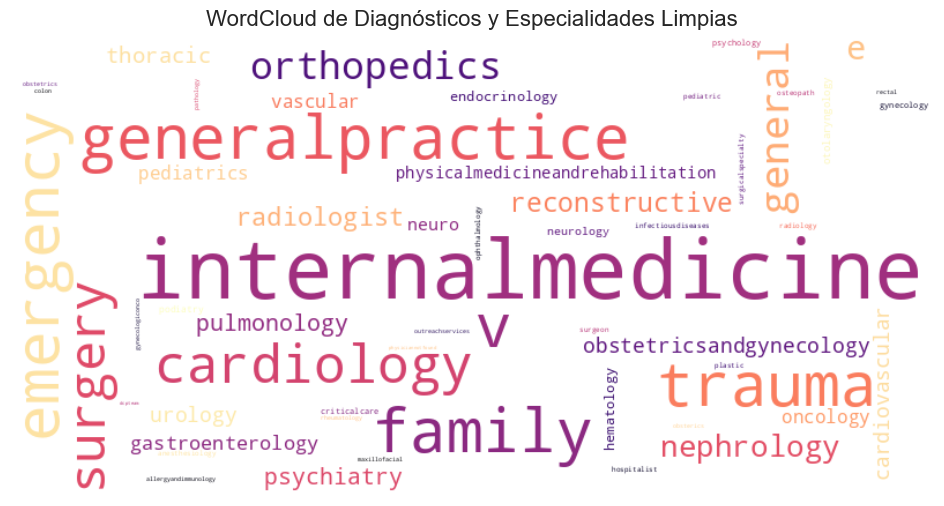

In [ ]:
from pyspark.sql.functions import explode, split
from wordcloud import WordCloud

# Tokenizar (separar por espacio)
words_df = df_clean.select(explode(split(col('texto_limpio'), '\s+')).alias('word'))
words_df = words_df.filter((col('word') != '') & (col('word') != '?'))

# Calcular frecuencias
word_counts = words_df.groupBy('word').count().orderBy('count', ascending=False)

print("Top 15 palabras más frecuentes:")
word_counts.show(15)

# Generar WordCloud
word_counts_pd = word_counts.limit(100).toPandas()
# Convertimos el DataFrame de frecuencias a un diccionario para wordcloud
word_freq = dict(zip(word_counts_pd['word'], word_counts_pd['count']))

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate_from_frequencies(word_freq)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud de Diagnósticos y Especialidades Limpias', fontsize=16)
plt.show()

## Ver sobre "v" "e" y stopwords.

## Integrantes:

- Sebastian Mendieta
- Jean Villavicencio
- Byron Reyes